<a href="https://colab.research.google.com/github/noelivander/BD-2/blob/main/prepare_data_TolakRevisiUUTNI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mengimport & menampilkan file csv yang hendak di bersihkan

In [1]:
import pandas as pd

TolakRevisiUUTNI = pd.read_csv('TolakRevisiUUTNI.csv')
print(TolakRevisiUUTNI.head())

   conversation_id_str                      created_at  favorite_count  \
0  1902799105015140742  Thu Mar 20 19:07:13 +0000 2025           86304   
1  1902963237597159474  Fri Mar 21 05:59:25 +0000 2025           30970   
2  1903045042681627122  Fri Mar 21 11:24:29 +0000 2025            6120   
3  1902613213931540874  Thu Mar 20 06:48:33 +0000 2025           36695   
4  1902584143256719763  Thu Mar 20 04:53:02 +0000 2025           39173   

                                           full_text               id_str  \
0  What I saw vs what I painted #TolakRevisiUUTNI...  1902799105015140742   
1  Jamuan hangat untuk para pengkhianat rakyat. #...  1902963237597159474   
2  FUCK POLICE #TolakRUUTNI #TolakRevisiUUTNI #Pe...  1903045042681627122   
3  stop ignorant. ini tuh NGARUH buat hidup lo. b...  1902613213931540874   
4  𝐂𝐨𝐫𝐚𝐤 𝐒𝐚𝐣𝐚𝐤: Lagi-lagi kita saksikan suara kit...  1902584143256719763   

                                           image_url in_reply_to_screen_name  \
0    https:/

Menampilkan struktur kolom dari data tersebut

In [2]:
TolakRevisiUUTNI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      201 non-null    int64 
 1   created_at               201 non-null    object
 2   favorite_count           201 non-null    int64 
 3   full_text                201 non-null    object
 4   id_str                   201 non-null    int64 
 5   image_url                198 non-null    object
 6   in_reply_to_screen_name  1 non-null      object
 7   lang                     201 non-null    object
 8   location                 135 non-null    object
 9   quote_count              201 non-null    int64 
 10  reply_count              201 non-null    int64 
 11  retweet_count            201 non-null    int64 
 12  tweet_url                201 non-null    object
 13  user_id_str              201 non-null    int64 
 14  username                 201 non-null    o

**Tahapan Cleaning Data**

Menampilkan isi kolom full_text yang berisi cuitan2 masyarakat

In [3]:
TolakRevisiUUTNI["full_text"]

,full_text
0,What I saw vs what I painted #TolakRevisiUUTNI...
1,Jamuan hangat untuk para pengkhianat rakyat. #...
2,FUCK POLICE #TolakRUUTNI #TolakRevisiUUTNI #Pe...
3,stop ignorant. ini tuh NGARUH buat hidup lo. b...
4,𝐂𝐨𝐫𝐚𝐤 𝐒𝐚𝐣𝐚𝐤: Lagi-lagi kita saksikan suara kit...
...,...
196,Udah gelap masih harus ditodong senjata lagi #...
197,ftd! Guys waktu kita TERBATAS! kalo gagal kita...
198,Neozen AYOK LEBIH BERISIK GUYSSS!! UDAH DESPER...
199,LIVE REPORT Unit ambulance berjaga disekitar U...


Sebuah fungsi cleaning untuk membersihkan simbol-simbol yang tidak penting/tak digunakan

In [4]:
#membuat function cleaning

import re
def clean(s):
    s = s.replace(r'<lb>', "\n")
    s = s.replace(r'<tab>', "\i")
    s = re.sub(r'<br */*>', "\n", s)
    s = s.replace("&lt;", "<").replace("&gt;", ">").replace("&amp;", "&")
    s = s.replace("&amp;", "&")
    # markdown urls
    s = re.sub(r'\(https*://[^\)]*\)', "", s)
    # normal urls
    s = re.sub(r'https*://[^\s]*', "", s)
    s = re.sub(r'_+', ' ', s)
    s = re.sub(r'"+', '"', s)
    return str(s)

Menyimpan hasilnya dalam sebuah variabel yang baru

In [5]:
TolakRevisiUUTNI["text_clean"] = ''

In [6]:
for i, row in TolakRevisiUUTNI.iterrows():
    TolakRevisiUUTNI.at[i, "text_clean"] = clean(row.full_text)

Menampilkan 5 data teratas

In [7]:
TolakRevisiUUTNI.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,text_clean
0,1902799105015140742,Thu Mar 20 19:07:13 +0000 2025,86304,What I saw vs what I painted #TolakRevisiUUTNI...,1902799105015140742,https://pbs.twimg.com/media/GmgZpP5bYAAnHOf.jpg,NaN,en,Sub Bass Signal,394,676,30991,https://x.com/Fairushit/status/190279910501514...,995583650824577024,Fairushit,What I saw vs what I painted #TolakRevisiUUTNI
1,1902963237597159474,Fri Mar 21 05:59:25 +0000 2025,30970,Jamuan hangat untuk para pengkhianat rakyat. #...,1902963237597159474,https://pbs.twimg.com/media/Gmiu-qObwAA33OY.jpg,NaN,in,NaN,248,742,16663,https://x.com/caracaltamer/status/190296323759...,1242287027007016962,caracaltamer,Jamuan hangat untuk para pengkhianat rakyat. #...
2,1903045042681627122,Fri Mar 21 11:24:29 +0000 2025,6120,FUCK POLICE #TolakRUUTNI #TolakRevisiUUTNI #Pe...,1903045042681627122,https://pbs.twimg.com/amplify_video_thumb/1903...,NaN,en,GF,36,577,2864,https://x.com/geemiily/status/1903045042681627122,1399153200779853830,geemiily,FUCK POLICE #TolakRUUTNI #TolakRevisiUUTNI #Pe...
3,1902613213931540874,Thu Mar 20 06:48:33 +0000 2025,36695,stop ignorant. ini tuh NGARUH buat hidup lo. b...,1902613213931540874,https://pbs.twimg.com/media/GmdwoYua8AIkHPn.jpg,NaN,in,she/her,249,2156,23272,https://x.com/halalazia/status/190261321393154...,1311629397321936897,halalazia,stop ignorant. ini tuh NGARUH buat hidup lo. b...
4,1902584143256719763,Thu Mar 20 04:53:02 +0000 2025,39173,𝐂𝐨𝐫𝐚𝐤 𝐒𝐚𝐣𝐚𝐤: Lagi-lagi kita saksikan suara kit...,1902584143256719763,https://pbs.twimg.com/media/GmdWLchaAAAIYXu.png,NaN,in,Nada Merawi. | 📖: 5/10.,187,370,25126,https://x.com/lokaterma/status/190258414325671...,1168503245515309058,lokaterma,𝐂𝐨𝐫𝐚𝐤 𝐒𝐚𝐣𝐚𝐤: Lagi-lagi kita saksikan suara kit...


Membandingkan data sebelum di clean dan setelah di clean

In [8]:
TolakRevisiUUTNI[["full_text", "text_clean"]].head()

,full_text,text_clean
0,What I saw vs what I painted #TolakRevisiUUTNI...,What I saw vs what I painted #TolakRevisiUUTNI
1,Jamuan hangat untuk para pengkhianat rakyat. #...,Jamuan hangat untuk para pengkhianat rakyat. #...
2,FUCK POLICE #TolakRUUTNI #TolakRevisiUUTNI #Pe...,FUCK POLICE #TolakRUUTNI #TolakRevisiUUTNI #Pe...
3,stop ignorant. ini tuh NGARUH buat hidup lo. b...,stop ignorant. ini tuh NGARUH buat hidup lo. b...
4,𝐂𝐨𝐫𝐚𝐤 𝐒𝐚𝐣𝐚𝐤: Lagi-lagi kita saksikan suara kit...,𝐂𝐨𝐫𝐚𝐤 𝐒𝐚𝐣𝐚𝐤: Lagi-lagi kita saksikan suara kit...


NLTK Process

Menginstal Natural Language Toolkit

In [ ]:
pip install nltk

mengunduh dataset

In [9]:
#tokenisasi
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize,word_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Contoh proses tokenisasi dalam bahasa inggris

In [10]:
example_text = "Hello there, how are you doing today? The weather is great today. The sky is blue. python is awsome"
print(sent_tokenize(example_text))
print(word_tokenize(example_text))

['Hello there, how are you doing today?', 'The weather is great today.', 'The sky is blue.', 'python is awsome']
['Hello', 'there', ',', 'how', 'are', 'you', 'doing', 'today', '?', 'The', 'weather', 'is', 'great', 'today', '.', 'The', 'sky', 'is', 'blue', '.', 'python', 'is', 'awsome']


melakukan tokenisasi pada data yang telah di clean & membandingkan data sebelum di tokenisasi dan setelah di tokenisasi

In [11]:
# Tokenisasi kata pada kolom 'text_clean'
TolakRevisiUUTNI['tokenized_text'] = TolakRevisiUUTNI['text_clean'].apply(lambda x: word_tokenize(x))

# Menampilkan beberapa baris pertama data dengan kolom tokenized_text
print(TolakRevisiUUTNI[['text_clean', 'tokenized_text']].head())


                                          text_clean  \
0    What I saw vs what I painted #TolakRevisiUUTNI    
1  Jamuan hangat untuk para pengkhianat rakyat. #...   
2  FUCK POLICE #TolakRUUTNI #TolakRevisiUUTNI #Pe...   
3  stop ignorant. ini tuh NGARUH buat hidup lo. b...   
4  𝐂𝐨𝐫𝐚𝐤 𝐒𝐚𝐣𝐚𝐤: Lagi-lagi kita saksikan suara kit...   

                                      tokenized_text  
0  [What, I, saw, vs, what, I, painted, #, TolakR...  
1  [Jamuan, hangat, untuk, para, pengkhianat, rak...  
2  [FUCK, POLICE, #, TolakRUUTNI, #, TolakRevisiU...  
3  [stop, ignorant, ., ini, tuh, NGARUH, buat, hi...  
4  [𝐂𝐨𝐫𝐚𝐤, 𝐒𝐚𝐣𝐚𝐤, :, Lagi-lagi, kita, saksikan, s...  


Menampilkan 5 data teratas setelah tokenisasi

In [12]:
TolakRevisiUUTNI["tokenized_text"].head()

,tokenized_text
0,"[What, I, saw, vs, what, I, painted, #, TolakR..."
1,"[Jamuan, hangat, untuk, para, pengkhianat, rak..."
2,"[FUCK, POLICE, #, TolakRUUTNI, #, TolakRevisiU..."
3,"[stop, ignorant, ., ini, tuh, NGARUH, buat, hi..."
4,"[𝐂𝐨𝐫𝐚𝐤, 𝐒𝐚𝐣𝐚𝐤, :, Lagi-lagi, kita, saksikan, s..."


Mengimport stopwords yang ada dalam bahasa indonesia

In [13]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words_indonesia = stopwords.words('indonesian')

stop_words_indonesia

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['ada',
 'adalah',
 'adanya',
 'adapun',
 'agak',
 'agaknya',
 'agar',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'amat',
 'amatlah',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasanya',
 'baik',
 'bakal',
 'bakalan',
 'balik',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah',
 'berada',
 'berakhir',
 'berakhirlah',
 'berakhirnya',
 'berapa',
 'berapakah',
 'berapalah',
 'berapapun',
 'berarti',
 'berawal',
 'berbagai',
 'berdatangan',
 'beri',
 'berikan',
 'berikut'

Contoh penerapan stopwords dalam bahasa inggris

In [14]:
from nltk.corpus import stopwords
text = 'he is a good boy. he is very good in coding'
text = word_tokenize(text)
text_with_no_stopwords = [word for word in text if word not in stopwords.words('english')]
text_with_no_stopwords

['good', 'boy', '.', 'good', 'coding']

Mengambil stopwords Indonesia, lalu menerapkan fungsi remove stopwords ke data yang telah di tokenisasi sebelumnya dan menampilkan hasilnya.

In [15]:
stop_words_indonesia = stopwords.words('indonesian')

def remove_stopwords(token_list):
  return [word for word in token_list if word.lower() not in stop_words_indonesia]

TolakRevisiUUTNI['tokenized_stopwords'] = TolakRevisiUUTNI['tokenized_text'].apply(remove_stopwords)

TolakRevisiUUTNI[['tokenized_text', 'tokenized_stopwords']].head()

,tokenized_text,tokenized_stopwords
0,"[What, I, saw, vs, what, I, painted, #, TolakR...","[What, I, saw, vs, what, I, painted, #, TolakR..."
1,"[Jamuan, hangat, untuk, para, pengkhianat, rak...","[Jamuan, hangat, pengkhianat, rakyat, ., #, To..."
2,"[FUCK, POLICE, #, TolakRUUTNI, #, TolakRevisiU...","[FUCK, POLICE, #, TolakRUUTNI, #, TolakRevisiU..."
3,"[stop, ignorant, ., ini, tuh, NGARUH, buat, hi...","[stop, ignorant, ., tuh, NGARUH, hidup, lo, .,..."
4,"[𝐂𝐨𝐫𝐚𝐤, 𝐒𝐚𝐣𝐚𝐤, :, Lagi-lagi, kita, saksikan, s...","[𝐂𝐨𝐫𝐚𝐤, 𝐒𝐚𝐣𝐚𝐤, :, Lagi-lagi, saksikan, suara, ..."


Contoh penerapan stemming

In [16]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()    ## Creating an object for porterstemmer
example_words = ['earn',"earning","earned","earns"]  ##Example words
for w in example_words:
    print(ps.stem(w))

earn
earn
earn
earn


Menginstal paket yang dibutuhkan

In [18]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.8 MB/s eta 0:00:00


Mengimport paket yang telah diinstal lalu membuat objek stemmer untuk membentuk fungsi steeming yang kemudian akan diterapkan pada data yang telah di stopwords sebelumnya & menampilkan hasilnya.

In [19]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming_sastrawi(token_list):
  return [stemmer.stem(word) for word in token_list]

TolakRevisiUUTNI['stemmed_words'] = TolakRevisiUUTNI['tokenized_stopwords'].apply(stemming_sastrawi)

TolakRevisiUUTNI[['tokenized_stopwords', 'stemmed_words']]

,tokenized_stopwords,stemmed_words
0,"[What, I, saw, vs, what, I, painted, #, TolakR...","[what, i, saw, vs, what, i, painted, , tolakre..."
1,"[Jamuan, hangat, pengkhianat, rakyat, ., #, To...","[jamu, hangat, khianat, rakyat, , , tolakruutn..."
2,"[FUCK, POLICE, #, TolakRUUTNI, #, TolakRevisiU...","[fuck, police, , tolakruutni, , tolakrevisiuut..."
3,"[stop, ignorant, ., tuh, NGARUH, hidup, lo, .,...","[stop, ignorant, , tuh, ngaruh, hidup, lo, , s..."
4,"[𝐂𝐨𝐫𝐚𝐤, 𝐒𝐚𝐣𝐚𝐤, :, Lagi-lagi, saksikan, suara, ...","[, , , lagi, saksi, suara, dengar, , , lokater..."
...,...,...
196,"[Udah, gelap, ditodong, senjata, #, TolakRUUTN...","[udah, gelap, todong, senjata, , tolakruutni, ..."
197,"[ftd, !, Guys, TERBATAS, !, kalo, gagal, gak, ...","[ftd, , guys, batas, , kalo, gagal, gak, suasa..."
198,"[Neozen, AYOK, BERISIK, GUYSSS, !, !, UDAH, DE...","[neozen, ayok, berisik, guysss, , , udah, desp..."
199,"[LIVE, REPORT, Unit, ambulance, berjaga, disek...","[live, report, unit, ambulance, jaga, sekitar,..."


In [21]:
# prompt: berikan saya syntax untuk membuat analisis sentimen untuk variabel stemmed_words

!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.6 MB/s eta 0:00:00


In [22]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Inisialisasi objek SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment(text_list):
    # Gabungkan list token menjadi satu string
    text = " ".join(text_list)

    # Lakukan analisis sentimen
    scores = analyzer.polarity_scores(text)

    # Kembalikan nilai compound score
    return scores['compound']

# Terapkan fungsi analyze_sentiment ke kolom 'stemmed_words'
TolakRevisiUUTNI['sentiment_score'] = TolakRevisiUUTNI['stemmed_words'].apply(analyze_sentiment)

In [23]:
# Menampilkan beberapa baris pertama data dengan kolom sentiment_score
print(TolakRevisiUUTNI[['stemmed_words', 'sentiment_score']].head())

                                       stemmed_words  sentiment_score
0  [what, i, saw, vs, what, i, painted, , tolakre...           0.0000
1  [jamu, hangat, khianat, rakyat, , , tolakruutn...           0.0000
2  [fuck, police, , tolakruutni, , tolakrevisiuut...          -0.5423
3  [stop, ignorant, , tuh, ngaruh, hidup, lo, , s...           0.2500
4  [, , , lagi, saksi, suara, dengar, , , lokater...           0.0000


In [24]:
# Membuat label setiap komentar

# Fungsi untuk menentukan label sentimen berdasarkan sentiment_score
def label_sentiment(score):
    if score < 0:
        return 'negatif'
    elif score == 0:
        return 'netral'
    else:
        return 'positif'

# Buat kolom baru 'sentiment_label' berdasarkan kolom 'sentiment_score'
TolakRevisiUUTNI['sentiment_label'] = TolakRevisiUUTNI['sentiment_score'].apply(label_sentiment)

# Menampilkan beberapa baris pertama data dengan kolom sentiment_label
print(TolakRevisiUUTNI[['stemmed_words', 'sentiment_score', 'sentiment_label']].head())


                                       stemmed_words  sentiment_score  \
0  [what, i, saw, vs, what, i, painted, , tolakre...           0.0000   
1  [jamu, hangat, khianat, rakyat, , , tolakruutn...           0.0000   
2  [fuck, police, , tolakruutni, , tolakrevisiuut...          -0.5423   
3  [stop, ignorant, , tuh, ngaruh, hidup, lo, , s...           0.2500   
4  [, , , lagi, saksi, suara, dengar, , , lokater...           0.0000   

  sentiment_label  
0          netral  
1          netral  
2         negatif  
3         positif  
4          netral  


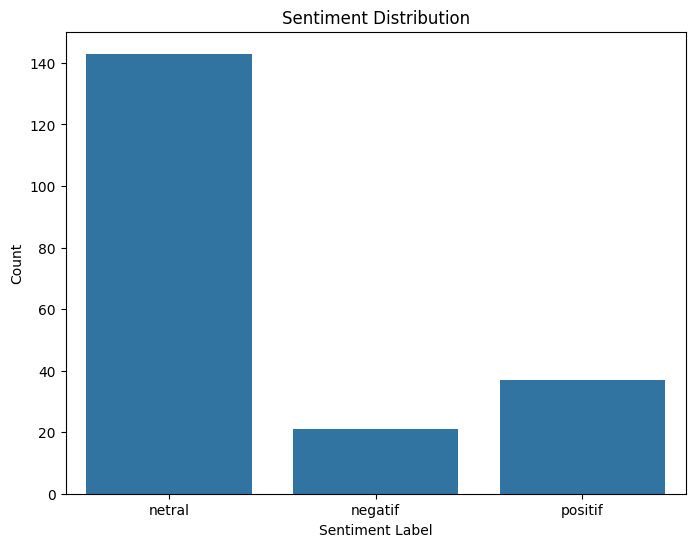

In [25]:
#Membuat grafik plot
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_label', data=TolakRevisiUUTNI)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

In [26]:
# prompt: Buat word cloud dari setiap kategori

!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

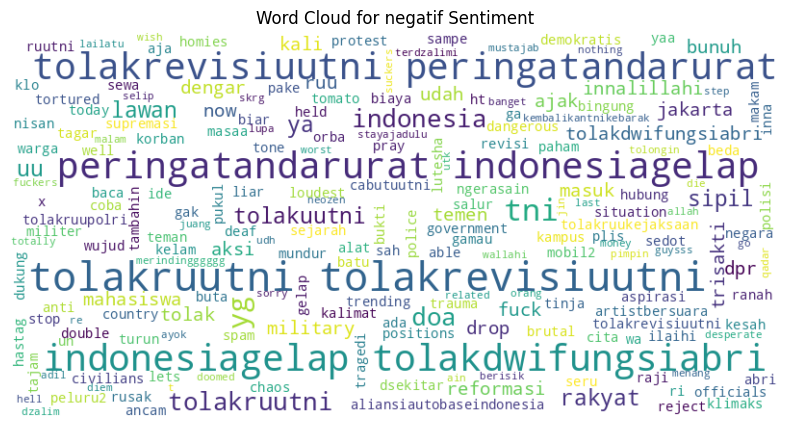

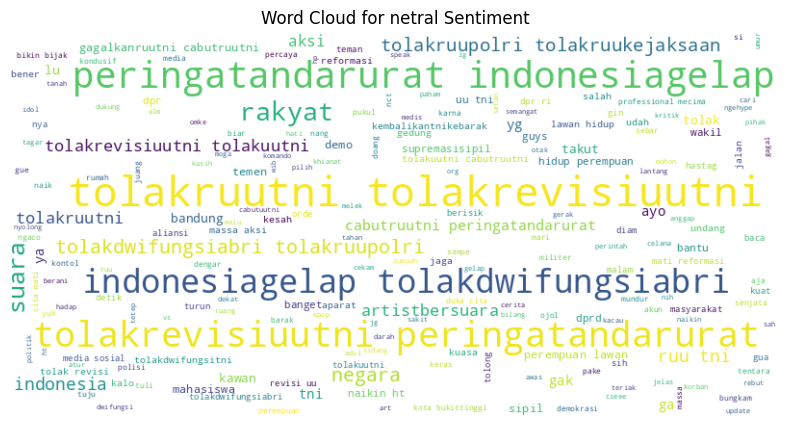

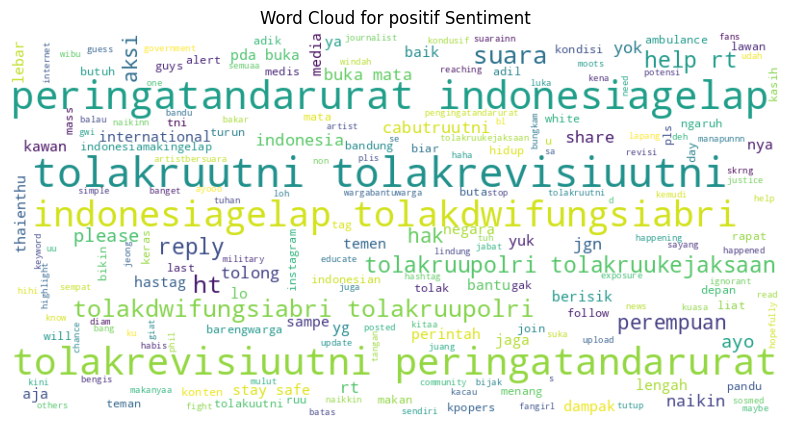

In [27]:
# Group data by sentiment label
sentiment_groups = TolakRevisiUUTNI.groupby('sentiment_label')

# Create word clouds for each sentiment category
for sentiment, group in sentiment_groups:
    # Combine all stemmed words in the group
    all_words = ' '.join([' '.join(words) for words in group['stemmed_words']])

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

    # Display the generated image:
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f'Word Cloud for {sentiment} Sentiment')
    plt.show()